# Somalia workflow: Step 3: Model-benchmark correlation (reanalysis)

NGA step 3 adapted: rank every candidate model series by its best
lag-adjusted **Spearman rho** against the flood benchmark, per river and
season.

**Naming note:** despite the NGA step name ("forecast correlation"), the
series correlated here are the models' **reanalysis/retrospective**
discharge, not forecasts: this notebook screens which model tracks which
river. Skill at actual forecast lead time is notebook 03's job. Two deliberate departures from Nigeria:

1. **Two benchmarks, per step 2's finding**: SFED (upper-reach buffer) AND
   the SWALIM reference-gauge level. On the Shabelle they disagree (1/6
   top-season overlap), so a gauge's rho against each tells us which flood
   history it actually tracks.
2. **Wider lag range** (-5 to +30 d vs NGA's -3 to +14): upstream stations
   sit days-to-weeks of travel time above the impact reaches, and SFED
   inundation lags discharge peaks.

Candidates: the 18 registry points x sources (GRRR 1980-2023, GloFAS v4
1999-2023, GloFAS v5, GEOGloWS retro): richer in sources than NGA's
GRRR-only pool, narrower in gauge count (a broader GRRR tributary sweep is a
possible follow-up).

**Output**: `som_gauge_correlations.parquet`: per (station, source, river,
season, benchmark): best_rho, best_lag, n_obs.

**What best_lag means:** for each model-benchmark pair, the model series is compared against the benchmark shifted by every lag from -5 to +30 days, and `best_lag` is the shift giving the strongest Spearman correlation (`best_rho`). A **positive lag of N** means the model's signal shows up **N days before** the benchmark: today's model discharge matches the gauge level (or FloodScan) N days from now, i.e. free warning time from river routing. Negative would mean the model trails the benchmark. Zero means they move together.

In [1]:
import sys

sys.path.insert(0, "..")

import os
import tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ocha_stratus as stratus
from scipy import stats as scipy_stats
import geopandas as gpd, tempfile, os

from src.constants import (
    TRIGGER_STATIONS,
    ALL_TRIGGER_STATIONS,
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
def load(name):
    return stratus.load_parquet_from_blob(f"ds-aa-som-floods/processed/{name}.parquet", stage="dev")

# v5 only (directive 2026-08-05). geoglows_sfdc is the SFDC-corrected
# GEOGloWS retrospective (notebook 02 section 4b): included because the
# correction is applied per calendar month, so it can move a seasonal
# rank correlation even though a single monotonic rescaling could not.
SOURCES = ["geoglows", "geoglows_sfdc", "google_grrr", "glofas_v5"]
dd = pd.concat([load(f"discharge_daily_{s}").assign(file_source=s) for s in SOURCES], ignore_index=True)
dd["date"] = pd.to_datetime(dd["date"])
# screen only the gauges the trigger can use (decision 2026-08-26)
dd = dd[dd.station.isin(ALL_TRIGGER_STATIONS)]

fs = load("workflow/som_floodscan_daily"); fs["date"] = pd.to_datetime(fs["date"])
lv = load("swalim_levels"); lv["date"] = pd.to_datetime(lv["date"])

MIN_LAG, MAX_LAG, MIN_OBS = -10, 30, 60
YEARS = (1998, 2023)

BENCHMARKS = {
    ("shabelle", "sfed"): fs[(fs.river == "shabelle") & (fs.segment == "upper")].set_index("date")["mean_sfed"],
    ("shabelle", "swalim"): lv[lv.station == "belet_weyne"].set_index("date")["level_m"],
    ("juba", "sfed"): fs[(fs.river == "juba") & (fs.segment == "upper")].set_index("date")["mean_sfed"],
    ("juba", "swalim"): lv[lv.station == "luuq"].set_index("date")["level_m"],
}
print("candidate series:", dd.groupby(["file_source"]).station.nunique().to_dict())


candidate series: {'geoglows': 7, 'geoglows_sfdc': 7, 'glofas_v5': 7, 'google_grrr': 7}


## Station map

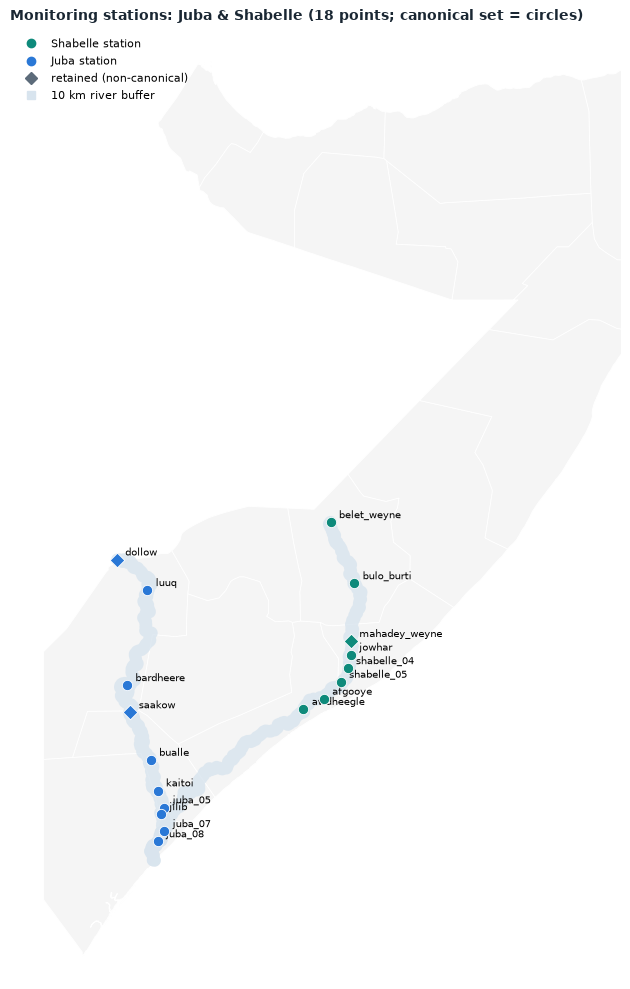

In [3]:
# admin boundaries + river buffers for context
adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

fig, ax = plt.subplots(figsize=(9, 10))
adm1.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.6)
bufs.plot(ax=ax, color="#D8E4EE", alpha=0.8)
RIVER_COLORS = {"shabelle": C_SHAB, "juba": C_JUBA}
for key, st in STATIONS.items():
    c = RIVER_COLORS[st.river]
    marker = "o" if st.canonical else "D"
    ax.scatter(st.lon, st.lat, color=c, marker=marker, s=55, zorder=5,
               edgecolors="white", linewidths=0.6)
    ax.annotate(key, (st.lon, st.lat), textcoords="offset points",
                xytext=(6, 3), fontsize=7)
handles = [
    plt.Line2D([], [], color=C_SHAB, marker="o", ls="", label="Shabelle station"),
    plt.Line2D([], [], color=C_JUBA, marker="o", ls="", label="Juba station"),
    plt.Line2D([], [], color=C_REF, marker="D", ls="", label="retained (non-canonical)"),
    plt.Line2D([], [], color="#D8E4EE", marker="s", ls="", label="10 km river buffer"),
]
ax.legend(handles=handles, loc="upper left", fontsize=8)
ax.set_xlim(40.5, 49.5); ax.set_ylim(-2, 12)
ax.set_title("Monitoring stations: Juba & Shabelle (18 points; canonical set = circles)", loc="left", fontsize=10)
ax.set_axis_off()
plt.tight_layout()


## Best-lag Spearman per candidate

Positive lag = the model series leads the benchmark by `lag` days (model
today correlates with benchmark `lag` days later): the operationally useful
direction.

In [4]:
def best_lag_corr(model, bench, months):
    m = model[model.index.month.isin(months)]
    m = m[(m.index.year >= YEARS[0]) & (m.index.year <= YEARS[1])]
    best_r, best_lag, best_n = 0.0, None, 0
    for lag in range(MIN_LAG, MAX_LAG + 1):
        b = bench.shift(-lag)
        j = pd.concat([m, b], axis=1, join="inner").dropna()
        if len(j) < MIN_OBS:
            continue
        r, _ = scipy_stats.spearmanr(j.iloc[:, 0], j.iloc[:, 1])
        if abs(r) > abs(best_r):
            best_r, best_lag, best_n = r, lag, len(j)
    return best_r, best_lag, best_n

rows = []
for (src, station, river), grp in dd.groupby(["file_source", "station", "river"]):
    model = grp.set_index("date")["discharge"]
    for season, months in SEASONS.items():
        for bname in ["sfed", "swalim"]:
            bench = BENCHMARKS[(river, bname)]
            r, lag, n = best_lag_corr(model, bench, months)
            if lag is None:
                continue
            rows.append({"station": station, "source": src, "river": river,
                         "season": season, "benchmark": bname,
                         "best_rho": round(r, 3), "best_lag": lag, "n_obs": n})
corr = pd.DataFrame(rows)
print(f"{len(corr)} correlation results")


112 correlation results


## Top candidates per river x season x benchmark

In [5]:
top = (corr.sort_values("best_rho", ascending=False)
       .groupby(["river", "season", "benchmark"]).head(5)
       .sort_values(["river", "season", "benchmark", "best_rho"], ascending=[1, 1, 1, 0]))
top.reset_index(drop=True)


,station,source,river,season,benchmark,best_rho,best_lag,n_obs
0,luuq,geoglows_sfdc,juba,deyr,sfed,0.422,12,2380
1,luuq,glofas_v5,juba,deyr,sfed,0.417,0,2300
2,bardheere,geoglows_sfdc,juba,deyr,sfed,0.394,11,2381
3,bardheere,glofas_v5,juba,deyr,sfed,0.382,-3,2300
4,dollow,glofas_v5,juba,deyr,sfed,0.370,10,2290
5,dollow,glofas_v5,juba,deyr,swalim,0.868,5,2087
6,luuq,glofas_v5,juba,deyr,swalim,0.849,3,2087
7,dollow,geoglows,juba,deyr,swalim,0.828,1,2087
8,luuq,geoglows,juba,deyr,swalim,0.818,-1,2088
9,bardheere,glofas_v5,juba,deyr,swalim,0.805,0,2087


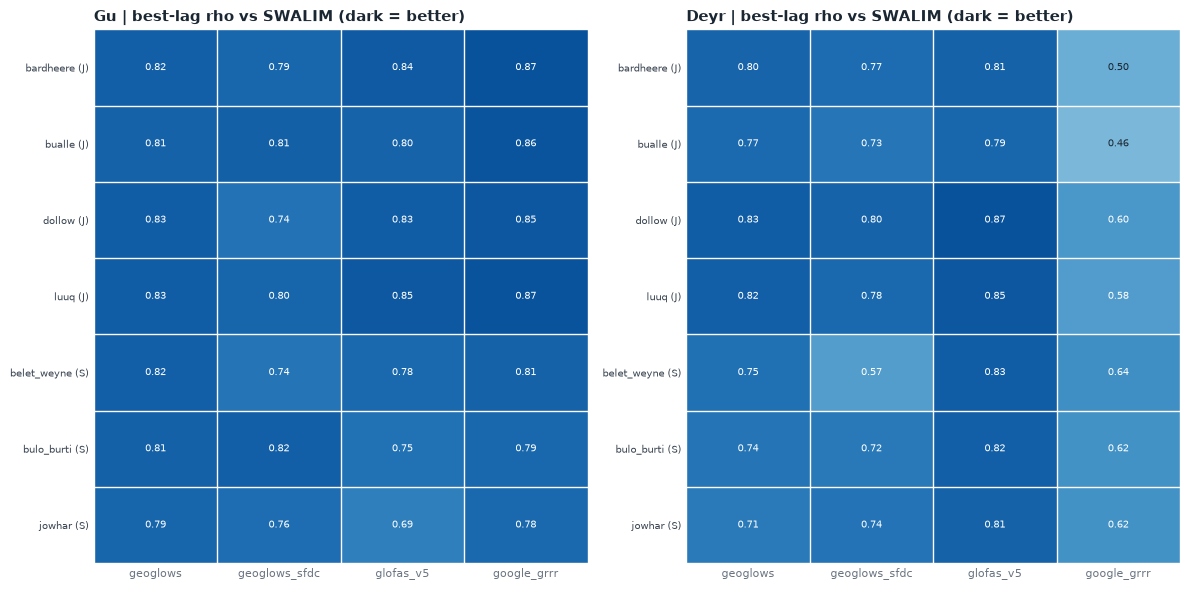

In [6]:
sw = corr[corr.benchmark == "swalim"]
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
for ax, season in zip(axes, ["gu", "deyr"]):
    sub = sw[sw.season == season]
    order = sub.drop_duplicates("station").sort_values(["river", "station"])
    piv = sub.pivot_table(index="station", columns="source", values="best_rho").loc[order.station]
    vals = piv.values
    ax.imshow(vals, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, fontsize=8)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(
        [f"{r.station} ({r.river[0].upper()})" for _, r in order.iterrows()],
        fontsize=7.5,
    )
    ax.set_xticks([x - 0.5 for x in range(len(piv.columns) + 1)], minor=True)
    ax.set_yticks([y - 0.5 for y in range(len(piv.index) + 1)], minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.tick_params(which="both", length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    for (i, j), v in np.ndenumerate(vals):
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.55 else INK)
    ax.set_title(f"{season.capitalize()} | best-lag rho vs SWALIM (dark = better)",
                 fontsize=10.5)
plt.tight_layout()


**Does correcting GEOGloWS change the screening?** `geoglows_sfdc` above is
the bias-corrected retrospective. Compare its rho against raw `geoglows` in
the tables and heatmaps: a monotonic rescaling cannot change a rank
correlation, but the SFDC correction is fitted per calendar month, so within
a season it is not a single monotonic transform and the rho can move. If it
moves enough to clear the selection floor, whether corrected GEOGloWS should
become eligible in notebook 07 is a decision for the working group: it still
has no long forecast archive to validate on.


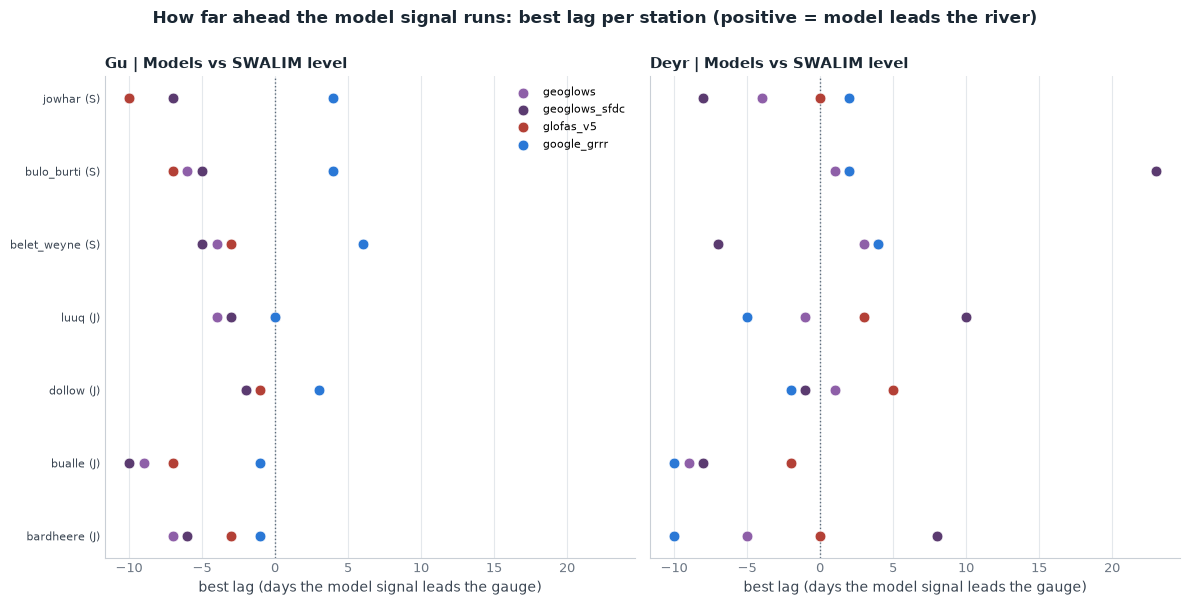

In [7]:
sw = corr[corr.benchmark == "swalim"]
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, sharex=True)
for ax, season in zip(axes, ["gu", "deyr"]):
    sub = sw[sw.season == season]
    order = sub.drop_duplicates("station").sort_values(["river", "station"])
    ypos = {s: i for i, s in enumerate(order.station)}
    for src_name, g in sub.groupby("source"):
        ax.scatter(
            g.best_lag,
            [ypos[s] for s in g.station],
            color=SOURCE_COLORS[src_name],
            s=60,
            label=src_name,
            edgecolors="white",
            linewidths=0.5,
            zorder=5,
        )
    ax.axvline(0, color=C_REF, ls=":", lw=1)
    ax.set_yticks(range(len(ypos)))
    ax.set_yticklabels(
        [f"{r.station} ({r.river[0].upper()})" for _, r in order.iterrows()],
        fontsize=8,
    )
    ax.invert_yaxis()
    ax.set_xlabel("best lag (days the model signal leads the gauge)")
    ax.set_title(f"{season.capitalize()} | Models vs SWALIM level", fontsize=10.5)
    style_ax(ax)
axes[0].legend(fontsize=8)
fig.suptitle(
    "How far ahead the model signal runs: best lag per station (positive = model leads the river)",
    fontweight="bold",
    color=INK,
    fontsize=12,
    y=1.0,
)
plt.tight_layout()


In [8]:
# full reanalysis correlation table: best-lag rho by source (vs SWALIM level)
corr[corr.benchmark == "swalim"].pivot_table(
    index=["river", "station"], columns=["source", "season"], values="best_rho"
).round(2)


source               geoglows       geoglows_sfdc       glofas_v5        \
season                   deyr    gu          deyr    gu      deyr    gu   
river    station                                                          
juba     bardheere       0.80  0.82          0.77  0.79      0.80  0.84   
         bualle          0.77  0.81          0.73  0.81      0.79  0.80   
         dollow          0.83  0.83          0.80  0.74      0.87  0.83   
         luuq            0.82  0.83          0.78  0.80      0.85  0.85   
shabelle belet_weyne     0.75  0.82          0.57  0.74      0.83  0.78   
         bulo_burti      0.74  0.81          0.72  0.82      0.82  0.75   
         jowhar          0.71  0.79          0.74  0.76      0.81  0.69   

source               google_grrr        
season                      deyr    gu  
river    station                        
juba     bardheere          0.50  0.87  
         bualle             0.46  0.86  
         dollow             0.60  0.85  
         luuq               0.58  0.87  
shabelle belet_weyne        0.64  0.81  
         bulo_burti         0.62  0.79  
         jowhar             0.62  0.78

## Which benchmark do the models track? (median best-rho by source)

In [9]:
piv = corr.pivot_table(index=["river", "season"], columns=["benchmark", "source"],
                       values="best_rho", aggfunc="median").round(2)
piv


benchmark           sfed                                       swalim  \
source          geoglows geoglows_sfdc glofas_v5 google_grrr geoglows   
river    season                                                         
juba     deyr       0.35          0.36      0.38        0.00     0.81   
         gu        -0.37         -0.39     -0.39       -0.42     0.82   
shabelle deyr       0.42          0.38      0.40        0.26     0.74   
         gu         0.42          0.46      0.35        0.42     0.81   

benchmark                                            
source          geoglows_sfdc glofas_v5 google_grrr  
river    season                                      
juba     deyr            0.77      0.83        0.54  
         gu              0.79      0.83        0.86  
shabelle deyr            0.72      0.82        0.62  
         gu              0.76      0.75        0.79

### Distribution view

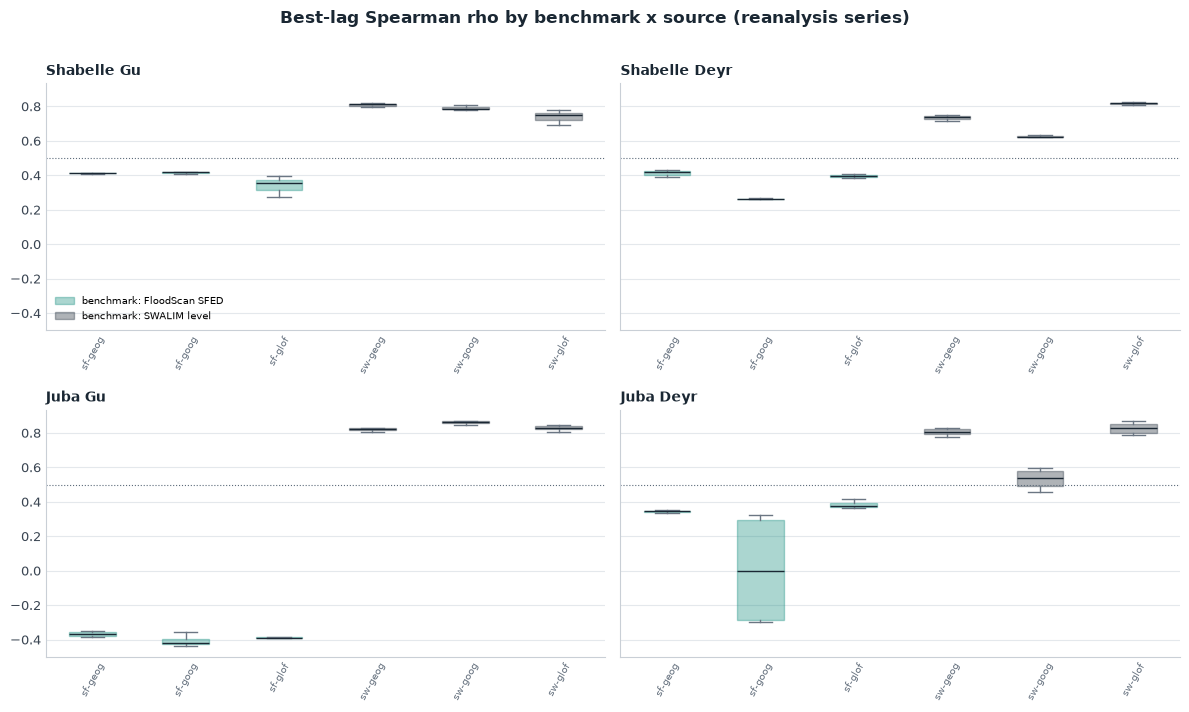

In [10]:
BM_COLORS = {"sfed": C_SFED, "swalim": C_SWALIM}
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for i, river in enumerate(["shabelle", "juba"]):
    for j, season in enumerate(["gu", "deyr"]):
        ax = axes[i][j]
        sub = corr[(corr.river == river) & (corr.season == season)]
        data, labels, cols = [], [], []
        for bname in ["sfed", "swalim"]:
            for src in ["geoglows", "google_grrr", "glofas_v5"]:
                vals = sub[(sub.benchmark == bname) & (sub.source == src)]["best_rho"]
                data.append(vals.values)
                labels.append(f"{bname[:2]}-{src.split('_')[0][:4]}")
                cols.append(BM_COLORS[bname])
        bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
        for patch, c in zip(bp["boxes"], cols):
            patch.set_facecolor(c)
            patch.set_alpha(0.35)
            patch.set_edgecolor(c)
        for med in bp["medians"]:
            med.set_color(INK)
        for part in ["whiskers", "caps"]:
            for ln in bp[part]:
                ln.set_color(FAINT)
        ax.set_title(f"{river.capitalize()} {season.capitalize()}", fontsize=10)
        ax.tick_params(axis="x", rotation=60, labelsize=7)
        ax.axhline(0.5, color=C_REF, ls=":", lw=0.8)
        style_ax(ax, grid="y")
axes[0][0].legend(
    handles=[
        mpatches.Patch(
            facecolor=BM_COLORS["sfed"],
            edgecolor=BM_COLORS["sfed"],
            alpha=0.35,
            label="benchmark: FloodScan SFED",
        ),
        mpatches.Patch(
            facecolor=BM_COLORS["swalim"],
            edgecolor=BM_COLORS["swalim"],
            alpha=0.35,
            label="benchmark: SWALIM level",
        ),
    ],
    fontsize=7,
    loc="lower left",
)
plt.suptitle(
    "Best-lag Spearman rho by benchmark x source (reanalysis series)",
    y=1.01,
    fontweight="bold",
    color=INK,
)
plt.tight_layout()


## Save

### Forecast-side correlation: does the screening transfer?

The screening above uses reanalysis because it is the only series long and
continuous enough to rank all 18 stations (benchmarks span 1998-2023).
Here the same best-lag correlation is computed on the **actual forecast
archives** for the sources that have them: Google GRRR (deterministic,
2016-2023) and GloFAS **v4** ensemble median: the 50%-of-members point (2003-2023, twice-weekly,
flood-season months; v4 because v5 publishes no reforecast, so treat the
GloFAS comparison as indicative across versions). GEOGloWS is excluded:
its archive begins mid-2024, after the benchmarks end. The chart shows the forecast archives only (dot = rho averaged across
leads 1-7 | thin bar = min-max over those leads; a short bar = skill
flat in lead). Compare against the reanalysis table above: close values
mean the screening transfers.


In [11]:
rf_gr = load("reforecast_google_grrr")
rf_gr["valid_time"] = pd.to_datetime(rf_gr["valid_time"])
rf_gf = load("reforecast_glofas_v4")
rf_gf["valid_time"] = pd.to_datetime(rf_gf["valid_time"])
# ensemble MEDIAN = the value that 50% of members exceed (the 50% rule)
gf_p50 = (
    rf_gf.groupby(["station", "valid_time", "leadtime_days"])["discharge"]
    .median()
    .reset_index()
)
FC = {
    "google_grrr": rf_gr[rf_gr.leadtime_days >= 1],
    "glofas_v4": gf_p50,
}
fc_rows = []
for src_name, d in FC.items():
    for station, grp in d.groupby("station"):
        river = STATIONS[station].river
        for lead in range(1, 8):
            m = (
                grp[grp.leadtime_days == lead]
                .set_index("valid_time")["discharge"]
                .sort_index()
            )
            for season, months in SEASONS.items():
                for bname in ["sfed", "swalim"]:
                    bench = BENCHMARKS[(river, bname)]
                    r, lag, n = best_lag_corr(m, bench, months)
                    if lag is None:
                        continue
                    fc_rows.append(
                        {
                            "station": station,
                            "source": src_name,
                            "river": river,
                            "season": season,
                            "benchmark": bname,
                            "lead": lead,
                            "fc_rho": round(r, 3),
                            "fc_lag": lag,
                            "n_obs": n,
                        }
                    )
fc_corr = pd.DataFrame(fc_rows)
print(f"{len(fc_corr)} forecast correlation results")
fc_corr[fc_corr.benchmark == "swalim"].pivot_table(
    index=["river", "station"], columns=["source", "season", "lead"], values="fc_rho"
).round(2)


952 forecast correlation results


source                 glofas_v4                                            \
season                      deyr                                        gu   
lead                           1     2     3     4     5     6     7     1   
river    station                                                             
juba     bardheere          0.80  0.80  0.81  0.82  0.81  0.82  0.83  0.84   
         bualle             0.80  0.80  0.80  0.81  0.80  0.81  0.82  0.84   
         dollow             0.80  0.81  0.82  0.83  0.82  0.83  0.84  0.84   
         jilib              0.80  0.80  0.80  0.81  0.80  0.81  0.82  0.84   
         juba_05            0.80  0.80  0.80  0.81  0.80  0.81  0.82  0.84   
         juba_07             NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
         juba_08             NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
         kaitoi             0.80  0.80  0.80  0.81  0.80  0.81  0.82  0.84   
         luuq               0.80  0.81  0.82  0.82  0.82  0.83  0.84  0.84   
         saakow             0.80  0.80  0.81  0.81  0.81  0.82  0.82  0.84   
shabelle afgooye            0.72  0.73  0.74  0.74  0.73  0.74  0.74  0.85   
         awdheegle          0.72  0.73  0.73  0.74  0.73  0.74  0.74  0.85   
         belet_weyne        0.74  0.74  0.75  0.75  0.74  0.74  0.74  0.84   
         bulo_burti         0.74  0.74  0.74  0.75  0.74  0.74  0.74  0.84   
         jowhar             0.74  0.74  0.75  0.75  0.74  0.74  0.74  0.84   
         mahadey_weyne      0.74  0.74  0.75  0.75  0.74  0.74  0.74  0.84   
         shabelle_04        0.73  0.73  0.74  0.74  0.73  0.74  0.74  0.85   
         shabelle_05        0.72  0.73  0.74  0.74  0.73  0.74  0.74  0.85   

source                              ... google_grrr                          \
season                              ...        deyr                gu         
lead                       2     3  ...           5     6     7     1     2   
river    station                    ...                                       
juba     bardheere      0.84  0.84  ...        0.57  0.58  0.58  0.88  0.88   
         bualle         0.84  0.84  ...        0.53  0.54  0.54  0.87  0.87   
         dollow         0.83  0.83  ...        0.69  0.70  0.70  0.88  0.88   
         jilib          0.84  0.84  ...        0.53  0.53  0.54  0.87  0.86   
         juba_05        0.84  0.84  ...        0.53  0.53  0.54  0.87  0.86   
         juba_07         NaN   NaN  ...        0.50  0.51  0.51  0.77  0.77   
         juba_08         NaN   NaN  ...        0.41  0.41  0.41  0.80  0.80   
         kaitoi         0.84  0.84  ...        0.53  0.53  0.54  0.87  0.87   
         luuq           0.83  0.83  ...        0.70  0.70  0.70  0.88  0.88   
         saakow         0.84  0.84  ...        0.55  0.56  0.56  0.88  0.87   
shabelle afgooye        0.85  0.85  ...        0.63  0.63  0.63  0.73  0.72   
         awdheegle      0.85  0.85  ...        0.64  0.64  0.65  0.74  0.74   
         belet_weyne    0.84  0.84  ...        0.60  0.60  0.60  0.80  0.80   
         bulo_burti     0.84  0.84  ...        0.61  0.60  0.61  0.72  0.73   
         jowhar         0.84  0.84  ...        0.61  0.61  0.62  0.71  0.72   
         mahadey_weyne  0.84  0.84  ...        0.62  0.62  0.62  0.71  0.72   
         shabelle_04    0.85  0.85  ...        0.62  0.62  0.62  0.71  0.71   
         shabelle_05    0.85  0.85  ...        0.63  0.63  0.63  0.73  0.72   

source                                                
season                                                
lead                       3     4     5     6     7  
river    station                                      
juba     bardheere      0.88  0.88  0.88  0.88  0.88  
         bualle         0.87  0.87  0.87  0.86  0.86  
         dollow         0.88  0.88  0.89  0.89  0.88  
         jilib          0.86  0.86  0.86  0.86  0.86  
         juba_05        0.86  0.86  0.86  0.86  0.86  
         juba_07        0.77  0.77  0.77  0.78  0

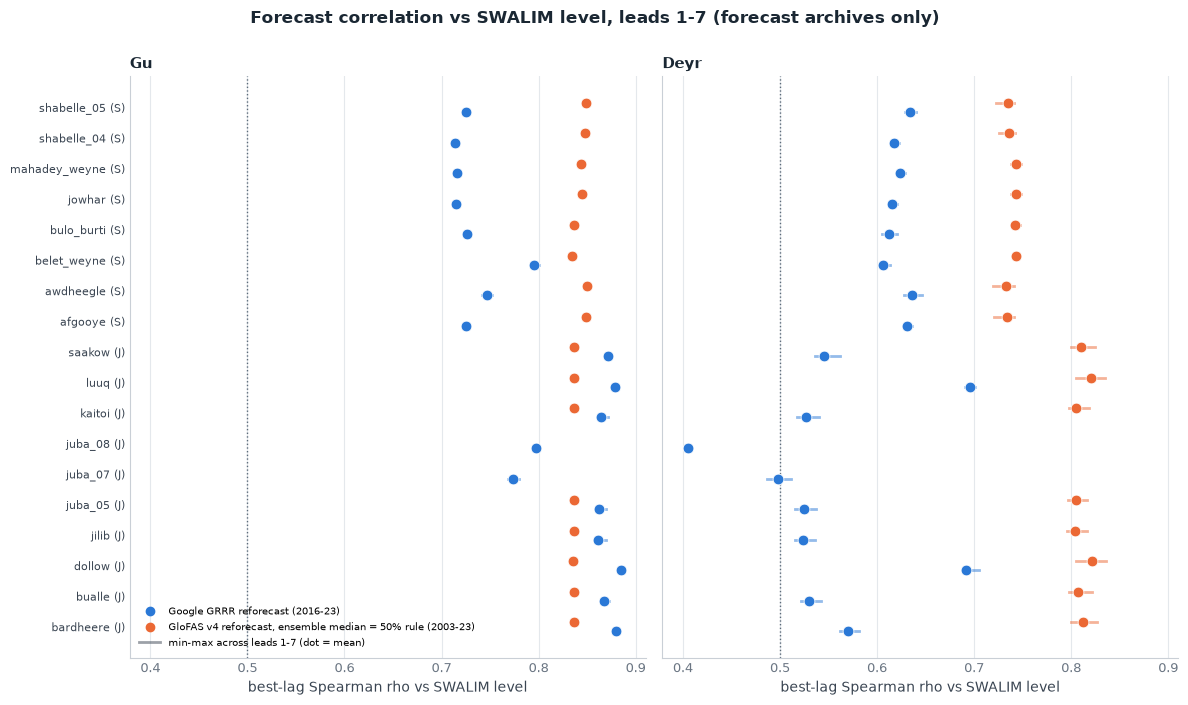

In [12]:
FC_COLORS = {"google_grrr": C_GOOGLE, "glofas_v4": C_GLOFAS4}
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, sharex=True)
sw_fc = fc_corr[fc_corr.benchmark == "swalim"]
for ax, season in zip(axes, ["gu", "deyr"]):
    sub_fc = sw_fc[sw_fc.season == season]
    order = sub_fc.drop_duplicates("station").sort_values(["river", "station"])
    ypos = {s: i for i, s in enumerate(order.station)}
    for src_name, color in FC_COLORS.items():
        off = -0.15 if src_name == "google_grrr" else 0.15
        for station, g in sub_fc[sub_fc.source == src_name].groupby("station"):
            y = ypos[station] + off
            ax.plot([g.fc_rho.min(), g.fc_rho.max()], [y, y],
                    color=color, lw=2, alpha=0.5, zorder=3)
            ax.scatter(g.fc_rho.mean(), y, color=color, s=60,
                       edgecolors="white", linewidths=0.6, zorder=5)
    ax.axvline(0.5, color=C_REF, ls=":", lw=1)
    ax.set_yticks(range(len(ypos)))
    ax.set_yticklabels(
        [f"{r.station} ({r.river[0].upper()})" for _, r in order.iterrows()],
        fontsize=8,
    )
    ax.invert_yaxis()
    ax.set_xlabel("best-lag Spearman rho vs SWALIM level")
    ax.set_title(f"{season.capitalize()}", fontsize=10.5)
    style_ax(ax)
handles = [
    plt.Line2D([], [], color=C_GOOGLE, marker="o", ls="", label="Google GRRR reforecast (2016-23)"),
    plt.Line2D([], [], color=C_GLOFAS4, marker="o", ls="", label="GloFAS v4 reforecast, ensemble median = 50% rule (2003-23)"),
    plt.Line2D([], [], color=BODY, lw=2, alpha=0.5, label="min-max across leads 1-7 (dot = mean)"),
]
axes[0].legend(handles=handles, fontsize=7.5, loc="lower left")
fig.suptitle(
    "Forecast correlation vs SWALIM level, leads 1-7 (forecast archives only)",
    fontweight="bold", color=INK, fontsize=12, y=1.0,
)
plt.tight_layout()


In [13]:
# forecast correlation per station and model (mean across leads 1-7)
fc_corr[fc_corr.benchmark == "swalim"].pivot_table(
    index=["river", "station"], columns=["source", "season"], values="fc_rho"
).round(2)


source                 glofas_v4       google_grrr      
season                      deyr    gu        deyr    gu
river    station                                        
juba     bardheere          0.81  0.84        0.57  0.88
         bualle             0.81  0.84        0.53  0.87
         dollow             0.82  0.84        0.69  0.88
         jilib              0.80  0.84        0.52  0.86
         juba_05            0.80  0.84        0.52  0.86
         juba_07             NaN   NaN        0.50  0.77
         juba_08             NaN   NaN        0.41  0.80
         kaitoi             0.81  0.84        0.53  0.86
         luuq               0.82  0.84        0.70  0.88
         saakow             0.81  0.84        0.55  0.87
shabelle afgooye            0.73  0.85        0.63  0.73
         awdheegle          0.73  0.85        0.64  0.75
         belet_weyne        0.74  0.83        0.61  0.80
         bulo_burti         0.74  0.84        0.61  0.73
         jowhar             0.74  0.84        0.62  0.71
         mahadey_weyne      0.74  0.84        0.62  0.72
         shabelle_04        0.74  0.85        0.62  0.71
         shabelle_05        0.73  0.85        0.63  0.73

In [14]:
stratus.upload_parquet_to_blob(
    corr, "ds-aa-som-floods/processed/workflow/som_gauge_correlations.parquet", stage="dev")
print(f"uploaded som_gauge_correlations.parquet ({len(corr)} rows)")

stratus.upload_parquet_to_blob(
    fc_corr,
    "ds-aa-som-floods/processed/workflow/som_gauge_correlations_forecast.parquet",
    stage="dev",
)
print(f"uploaded som_gauge_correlations_forecast.parquet ({len(fc_corr)} rows)")


uploaded som_gauge_correlations.parquet (112 rows)
uploaded som_gauge_correlations_forecast.parquet (952 rows)
